# Dataset: AI vs Human Text dataset

**Descripción:**
Un conjunto de datos limpio y estructurado para clasificar texto como generado por IA o escrito por humanos. Adecuado para tareas de PLN, clasificación y evaluación de modelos.

**Contexto:**
Con el auge del contenido generado por IA, distinguir entre texto escrito por humanos y máquinas se ha vuelto importante para la investigación, seguridad y verificación de contenido.

**Distribución de características:**

- Longitud del Texto: Varía de pasajes cortos a largos
- Conteo de Palabras: Amplio rango entre muestras
- Estructura de Oraciones: Patrones simples a complejos
- Diversidad de Vocabulario: Diferentes niveles de riqueza en el uso de palabras
- Etiqueta: Binaria (Generado por IA = 1, Escrito por Humanos = 0)

# Explicación del Proceso

1. Preprocesamiento de los datos
    - Normalizar los datos -> Todo minusculas, quitar caracteres especiales 
    - Eliminar STOP WORD (conectores)
2. Entrenar la red neuronal 
3. Entrenar la red neuronal con lematizacion
    - Aplicar Lematizacion a los datos sin STOP WORDS 
    - Entrenar la misma configuracion de red neuronal

# Preprocesamiento de los datos 

In [24]:
import pandas as pd 
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import keras
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('data_for_preprocessing.csv')
print(df.head())

print ("----------------------")
print(f"Total: \n{df['Author'].value_counts()}")

   Unnamed: 0                                               Text Author
0           0  This study investigates the chemical compositi...     AI
1           1  This study explores the cultural history of oi...     AI
2           2   Isolation of human peripheral blood mononucle...  Human
3           3   Dynamic Bayesian Networks (DBNs) are probabil...  Human
4           4   Within volleyball, performance analysis is em...  Human
----------------------
Total: 
Author
AI       3069
Human    3000
Name: count, dtype: int64


In [5]:
def comparar (df):
    print("--- Comparativa de resultados ---")
    print(df[['Text', 'Text_limpia']].head())
    df['Text'] = df['Text_limpia']
    df.drop(columns=['Text_limpia'], inplace=True)

## Normalizar los datos

In [6]:
def normalize_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()
    
    # 2. Eliminar acentos (Convertir 'á' en 'a')
    # Normalizamos a forma NFD y luego descartamos los caracteres de acentuación
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode("utf-8")
    
    # 3. Eliminar caracteres especiales
    # Mantenemos solo letras (a-z), números (0-9) y espacios (\s)
    # El símbolo '^' significa "todo lo que NO sea esto"
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    return text

In [7]:
df['Text_limpia'] = df['Text'].apply(normalize_text)
comparar(df)

--- Comparativa de resultados ---
                                                Text  \
0  This study investigates the chemical compositi...   
1  This study explores the cultural history of oi...   
2   Isolation of human peripheral blood mononucle...   
3   Dynamic Bayesian Networks (DBNs) are probabil...   
4   Within volleyball, performance analysis is em...   

                                         Text_limpia  
0  this study investigates the chemical compositi...  
1  this study explores the cultural history of oi...  
2   isolation of human peripheral blood mononucle...  
3   dynamic bayesian networks dbns are probabilis...  
4   within volleyball performance analysis is emp...  


## Eliminar STOP WORDS

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df['Text_limpia'] = df['Text'].apply(remove_stopwords)
comparar(df)

--- Comparativa de resultados ---
                                                Text  \
0  this study investigates the chemical compositi...   
1  this study explores the cultural history of oi...   
2   isolation of human peripheral blood mononucle...   
3   dynamic bayesian networks dbns are probabilis...   
4   within volleyball performance analysis is emp...   

                                         Text_limpia  
0  study investigates chemical composition therma...  
1  study explores cultural history oil wrestling ...  
2  isolation human peripheral blood mononuclear c...  
3  dynamic bayesian networks dbns probabilistic m...  
4  within volleyball performance analysis employe...  


# Entrenar RNA sin Lematización
Pasos:
1. Codificar las variables 
2. Dividir entre entrenamiento y prueba 
3. Tokenizar las palabras 
4. Construir el modelo
5. Entrenar el modelo 


In [10]:
review = []
sentences = list(df['Text'])
for sentence in sentences:
    review.append(sentence)

labels = df['Author']
labels = np.array(list(map(lambda x: 1 if x == 'AI' else 0, labels)))
print(labels[:10])

[1 1 0 0 0 0 0 1 1 1]


In [11]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [12]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [13]:
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    # Bidirectional permite contexto en ambas direcciones
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # GlobalAveragePooling ayuda a reducir dimensiones y evita el sobreajuste
    layers.GlobalAveragePooling1D(),
    # Dropout es vital para evitar el sobreajuste (overfitting)
    layers.Dropout(0.5),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Clasificación binaria (sentimiento)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9872 - loss: 0.0877 - val_accuracy: 0.9951 - val_loss: 0.0191
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9934 - loss: 0.0316 - val_accuracy: 0.9934 - val_loss: 0.0188
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9932 - loss: 0.0292 - val_accuracy: 0.9951 - val_loss: 0.0161
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9936 - loss: 0.0280 - val_accuracy: 0.9967 - val_loss: 0.0141
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9940 - loss: 0.0303 - val_accuracy: 0.9934 - val_loss: 0.0218
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9940 - loss: 0.0294 - val_accuracy: 0.9951 - val_loss: 0.0168
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9949 - loss: 0.0285 - val_accuracy: 0.9967 - val_loss: 0.0157


<Axes: >

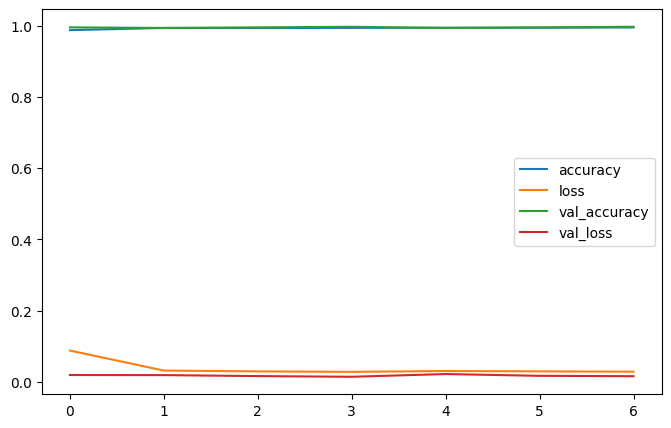

In [14]:
callback_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(padded, 
                    train_labels,epochs=20, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[callback_early])
pd.DataFrame(history.history).plot(figsize=(8,5))

# Entrenar RNA con Lematización

La lematización es un paso más avanzado que la limpieza básica. Mientras que el stemming simplemente corta los sufijos de las palabras (lo cual suele generar errores), la lematización utiliza un diccionario y análisis morfológico para devolver la palabra a su raíz (su "lema").
Por ejemplo:

- "Running" -> "Run"

- "Better" -> "Good"

- "Children" -> "Child"

Para esto usaremos `WordNetLemmatizer` de NLTK.

Pasos: 
0. Lematizar las frases
1. Codificar las variables 
2. Dividir entre entrenamiento y prueba 
3. Tokenizar las palabras 
4. Construir el modelo
5. Entrenar el modelo 



In [15]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    #Mapea las etiquetas POS de nltk a las que entiende WordNet
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]
    return " ".join(lemmatized_words)



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [16]:
df_lematizado = df.copy()
df_lematizado['Text_limpia'] = df_lematizado['Text'].apply(lemmatize_text)
comparar(df_lematizado)

--- Comparativa de resultados ---
                                                Text  \
0  study investigates chemical composition therma...   
1  study explores cultural history oil wrestling ...   
2  isolation human peripheral blood mononuclear c...   
3  dynamic bayesian networks dbns probabilistic m...   
4  within volleyball performance analysis employe...   

                                         Text_limpia  
0  study investigates chemical composition therma...  
1  study explores cultural history oil wrestling ...  
2  isolation human peripheral blood mononuclear c...  
3  dynamic bayesian network dbns probabilistic mo...  
4  within volleyball performance analysis employ ...  


In [18]:
review = []
sentences = list(df_lematizado['Text'])
for sentence in sentences:
    review.append(sentence)

labels = df_lematizado['Author']
labels = np.array(list(map(lambda x: 1 if x == 'AI' else 0, labels)))
print(labels[:10])

[1 1 0 0 0 0 0 1 1 1]


In [19]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [20]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [21]:
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    # Bidirectional permite contexto en ambas direcciones
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # GlobalAveragePooling ayuda a reducir dimensiones y evita el sobreajuste
    layers.GlobalAveragePooling1D(),
    # Dropout es vital para evitar el sobreajuste (overfitting)
    layers.Dropout(0.5),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Clasificación binaria (sentimiento)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9889 - loss: 0.0903 - val_accuracy: 0.9934 - val_loss: 0.0189
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9936 - loss: 0.0305 - val_accuracy: 0.9967 - val_loss: 0.0156
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9938 - loss: 0.0306 - val_accuracy: 0.9951 - val_loss: 0.0163
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9934 - loss: 0.0296 - val_accuracy: 0.9967 - val_loss: 0.0147
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9934 - loss: 0.0294 - val_accuracy: 0.9967 - val_loss: 0.0153
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9942 - loss: 0.0280 - val_accuracy: 0.9967 - val_loss: 0.0147
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9955 - loss: 0.0254 - val_accuracy: 0.9967 - val_loss: 0.0143
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9951 - loss: 0.0246 - val_accu

<Axes: >

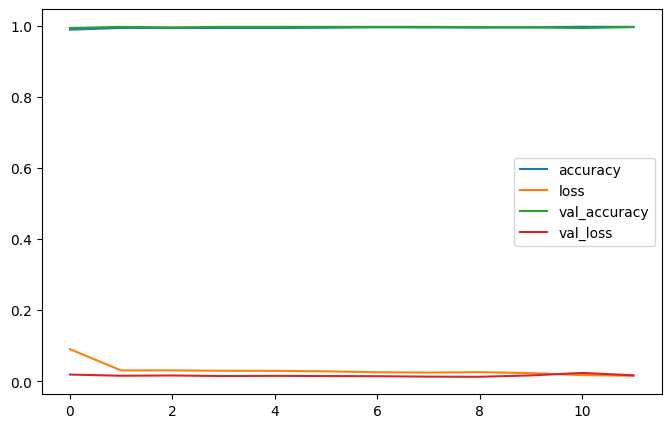

In [22]:
callback_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_lematizado = model.fit(padded, 
                    train_labels,epochs=20, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[callback_early])
pd.DataFrame(history_lematizado.history).plot(figsize=(8,5))

# Comparacion entre modelos

In [27]:
# Create DataFrames for the histories
df_history = pd.DataFrame(history.history)
df_history_lematizado = pd.DataFrame(history_lematizado.history)

# Print summary statistics tables
print("Statistics for history (without lemmatization):")
print(df_history.describe())
print("\nStatistics for history_lematizado (with lemmatization):")
print(df_history_lematizado.describe())



Statistics for history (without lemmatization):
       accuracy      loss  val_accuracy  val_loss
count  7.000000  7.000000      7.000000  7.000000
mean   0.992909  0.037817      0.995058  0.017499
std    0.002561  0.022048      0.001345  0.002577
min    0.987230  0.027989      0.993410  0.014145
25%    0.993306  0.028847      0.994234  0.015900
50%    0.993615  0.029384      0.995058  0.016817
75%    0.994027  0.030954      0.995881  0.018956
max    0.994851  0.087744      0.996705  0.021820

Statistics for history_lematizado (with lemmatization):
        accuracy       loss  val_accuracy   val_loss
count  12.000000  12.000000     12.000000  12.000000
mean    0.994301   0.030823      0.995744   0.016032
std     0.002083   0.019365      0.001258   0.002896
min     0.988877   0.015497      0.993410   0.012673
25%     0.993563   0.024141      0.995058   0.014573
50%     0.994439   0.026829      0.996293   0.015463
75%     0.995469   0.029827      0.996705   0.016628
max     0.996910   0.